# Week 7 - Function 2 ((16DP, 2D))

# Setup
Let's load all the imports in the top to avoid repeating and simplify the readability of each solution.

In [1]:
import numpy as np

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel
from sklearn.preprocessing import QuantileTransformer, MinMaxScaler
from scipy.stats.qmc import LatinHypercube

from utils.plotting_utils import plot_2D_mean_uncertainty, plot_bar


# Plan
We now have ((16, 2)) — 16 data points, 2 dimensions, from `./data/week_7/function_2/`.

**Architecture**: Single GP (Matern 2.5) with QuantileTransformer output and EI acquisition.

**Key decisions** (carried forward):
- QuantileTransformer: consistent with other functions; no outliers but uniform output keeps GP numerically stable
- EI acquisition: UCB (kappa=2 and 4) kept recommending x1≈1 boundary; EI anchors to y_best, ignoring low-predicted corners
- 10K LHS candidates for boundary-bias-free search

**Changes this week:**
- StandardScaler → QuantileTransformer (consistency)
- Acquisition upgraded from 50×50 meshgrid → 10K LHS candidates
- Added sanity check (corner detection)

**Steps:** Load data → Preprocessing → GP model → Acquisition → Report

# 1. Load data

Shape: X=(16, 2), y=(16,)
X range: [0.0287, 0.9266]
y range: [-0.0656, 0.6112]


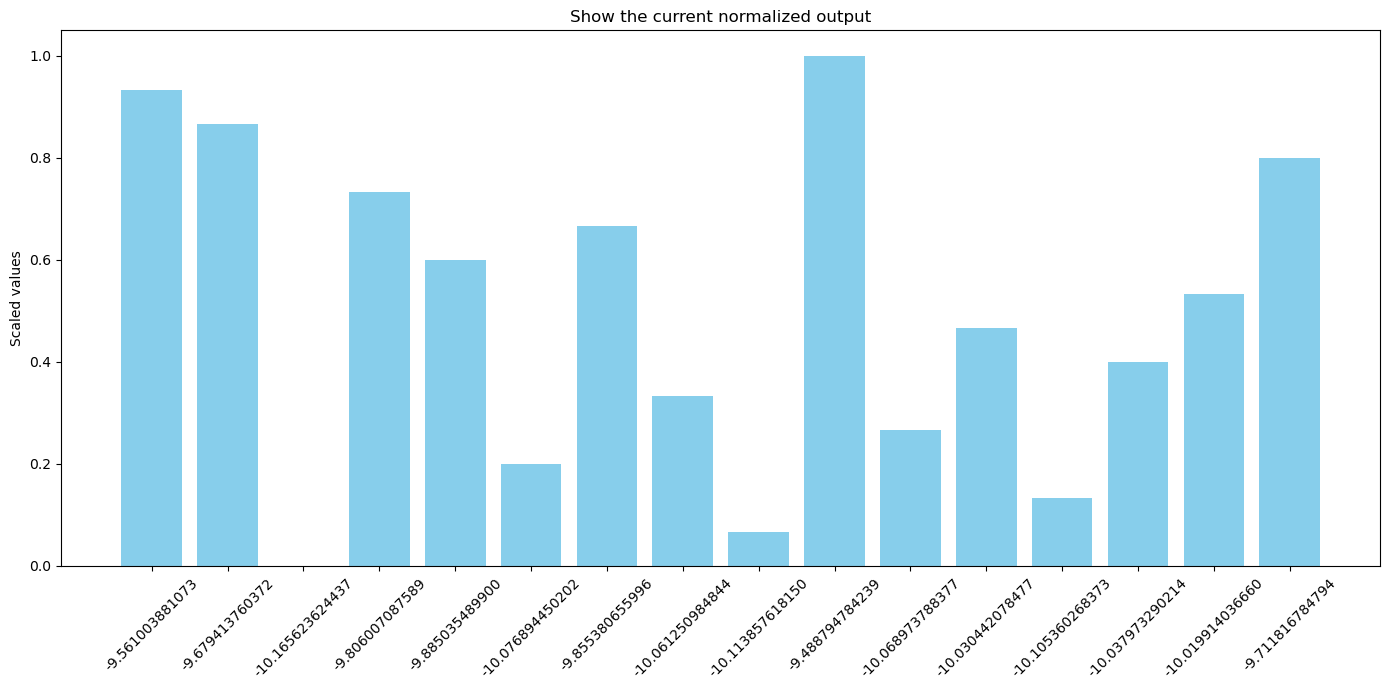

In [2]:
X_train_raw = np.load(r"./data/week_7/function_2/inputs.npy")
y_train_raw = np.load(r"./data/week_7/function_2/outputs.npy")

print(f"Shape: X={X_train_raw.shape}, y={y_train_raw.shape}")
print(f"X range: [{X_train_raw.min():.4f}, {X_train_raw.max():.4f}]")
print(f"y range: [{y_train_raw.min():.4f}, {y_train_raw.max():.4f}]")

scaler_X = MinMaxScaler()
scaler_y = QuantileTransformer(n_quantiles=len(y_train_raw), output_distribution='uniform')

X_train = scaler_X.fit_transform(X_train_raw)
y_train = scaler_y.fit_transform(y_train_raw.reshape(-1, 1)).ravel()

plot_bar(y_train_raw, y_train, 'Scaled values', 'Show the current normalized output')

# 2. Build probabilistic Model

Using QuantileTransformer (consistent with other functions) and a Matern 2.5 kernel.
The function has genuinely local structure (optimal ls ≈ 0.05), so the lower bound of 0.4
is intentionally constraining smoothness for visualization.

Optimized Kernel: 3.16**2 * Matern(length_scale=0.4, nu=2.5)


/opt/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__constant_value is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 0.4. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


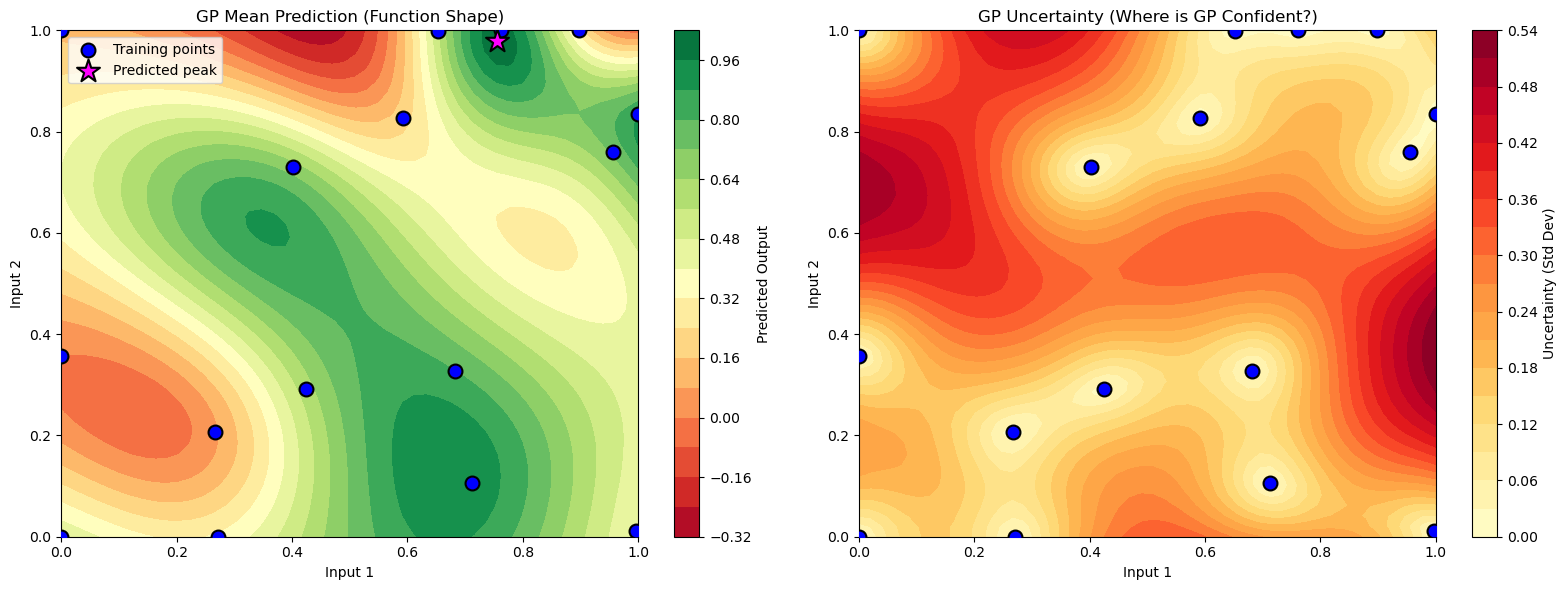

In [3]:
model = GaussianProcessRegressor(
    kernel=ConstantKernel(0.25, (1e-3, 10)) * Matern(
        length_scale=0.5,
        length_scale_bounds=(0.4, 10.0),  # lower bound enforces min smoothness for visualisation
        nu=2.5
    ),
    alpha=1e-6,
    normalize_y=True,
    n_restarts_optimizer=15
)

model.fit(X_train, y_train)

print(f"Optimized Kernel: {model.kernel_}")

# Create prediction grid
n_grid = 50
x1_range = np.linspace(0, 1, n_grid)
x2_range = np.linspace(0, 1, n_grid)

X1_test, X2_test = np.meshgrid(x1_range, x2_range)
X_grid = np.c_[X1_test.ravel(), X2_test.ravel()]

# Make predictions
mu, sigma = model.predict(X_grid, return_std=True)

plot_2D_mean_uncertainty(
   X_train,
   X1_test,
   X2_test,
   mu,
   sigma,
)

# 3. Acquisition function

Well-behaved 2D data with no outliers. Using UCB with kappa=2.0 (conservative, exploitation-focused).
LHS candidates replace the 50×50 meshgrid to avoid boundary bias; the grid is kept for visualization only.


In [4]:
from scipy.stats import norm as scipy_norm

def expected_improvement(mu, sigma, y_best, xi=0.0):
    """
    Expected Improvement acquisition function.
    EI = (mu - y_best - xi) * Phi(z) + sigma * phi(z)
    where z = (mu - y_best - xi) / sigma

    EI is anchored to the current best observed value, so it naturally
    avoids unsampled boundaries that UCB chases due to high sigma alone.
    """
    z = (mu - y_best - xi) / (sigma + 1e-9)
    return (mu - y_best - xi) * scipy_norm.cdf(z) + sigma * scipy_norm.pdf(z)


# Switched from UCB to EI (week 5).
# UCB with kappa=2 and kappa=4 both kept recommending x1≈1 (boundary), opposite
# corner from the known best at [0.703, 0.927]. UCB chases high-sigma regions even
# when mu is low; EI requires mu > y_best, so it ignores low-predicted unsampled corners.
WEEK = 7
print(f"Acquisition: Expected Improvement (WEEK {WEEK})")

# Boundary fix (week 7): clip candidates to [0.05, 0.95] to prevent EI from
# chasing high-sigma boundary regions. EI oscillated between opposite corners
# (x2≈1 in week 5, x2≈0 in week 7) because the GP sees high σ at unsampled edges.
X_lhs = LatinHypercube(d=2, seed=42).random(n=10_000)
X_lhs = np.clip(X_lhs, 0.05, 0.95)

# Tight exploit cluster around the known peak [0.703, 0.927].
# Oracle history shows the function drops from 0.611 → 0.080 with just Δx1=0.081
# at identical x2 — peak is extremely narrow. ±0.015 radius probes the GP's
# high-mean region around the only strong signal in the training data.
best_idx_train = np.argmax(y_train_raw)
x_best_scaled = X_train[best_idx_train]
rng_exploit = np.random.default_rng(seed=99)
exploit_cluster = x_best_scaled + rng_exploit.uniform(-0.015, 0.015, size=(2000, 2))
exploit_cluster = np.clip(exploit_cluster, 0.05, 0.95)

X_candidates = np.vstack([X_lhs, exploit_cluster])

mu_cand, sigma_cand = model.predict(X_candidates, return_std=True)

# y_best in the QT-scaled space that the GP was trained on (QT max = 1.0)
y_best_scaled = y_train.max()
ei_values = expected_improvement(mu_cand, sigma_cand, y_best_scaled)

print(f"\nExpected Improvement (10K LHS [clipped 0.05–0.95] + 2K tight exploit ±0.015):")
print(f"  Min: {ei_values.min():.6f}")
print(f"  Max: {ei_values.max():.6f}")
print(f"  Non-zero candidates: {(ei_values > 0).sum()}")

best_idx = np.argmax(ei_values)
x_next_norm = X_candidates[best_idx]
x_next_orig = scaler_X.inverse_transform([x_next_norm])[0]

print(f"\n{'='*80}")
print(f"RECOMMENDED NEXT POINT")
print(f"{'='*80}")
print(f"  Input: [{x_next_orig[0]:.6f}, {x_next_orig[1]:.6f}]")

y_pred_next, y_std_next = model.predict([x_next_norm], return_std=True)
y_pred_next_orig = scaler_y.inverse_transform([[y_pred_next[0]]])[0, 0]

print(f"\nPredicted output at this point:")
print(f"  {y_pred_next_orig:.6f}")

print(f"\nEI at this point: {ei_values[best_idx]:.6f}")
print(f"EI Range: {ei_values.min():.4f} to {ei_values.max():.4f}")

print(f"\nSanity check - is this a corner?")
for i in range(2):
    at_boundary = x_next_norm[i] < 0.05 or x_next_norm[i] > 0.95
    print(f"  x{i+1} = {x_next_norm[i]:.4f} {'<-- BOUNDARY!' if at_boundary else ''}")

print(f"\nCurrent best: X=[{X_train_raw[np.argmax(y_train_raw)][0]:.4f}, {X_train_raw[np.argmax(y_train_raw)][1]:.4f}], y={y_train_raw.max():.6f}")

X_next = x_next_orig
print(f"\nX_next = {X_next}")

# Machine-readable tag for get_submission.py
print(f"\nSUBMISSION: {'-'.join(f'{x:.6f}' for x in x_next_orig)}")

Acquisition: Expected Improvement (WEEK 7)

Expected Improvement (10K LHS [clipped 0.05–0.95] + 2K tight exploit ±0.015):
  Min: 0.000000
  Max: 0.062042
  Non-zero candidates: 11982

RECOMMENDED NEXT POINT
  Input: [0.410631, 0.532125]

Predicted output at this point:
  0.426880

EI at this point: 0.062042
EI Range: 0.0000 to 0.0620

Sanity check - is this a corner?
  x1 = 0.3645 
  x2 = 0.5607 

Current best: X=[0.7026, 0.9266], y=0.611205

X_next = [0.41063057 0.53212522]

SUBMISSION: 0.410631-0.532125
